# 리뷰 텍스트 분석

리뷰 텍스트가 AI 학습 데이터로 적합한지 길이와 URL 포함 여부 기준으로 품질 등급 분류

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':    
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
    
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('amazon_cleaned.csv')
print(df.shape)

(1212, 22)


In [21]:
df[['review_title', 'review_content']].head(3)

,review_title,review_content
0,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."


In [22]:
df['review_length'] = df['review_content'].str.len()

df['review_length'].describe()

count     1212.000000
mean      1326.578383
std       1765.924395
min         67.000000
25%        492.000000
50%        783.000000
75%       1340.000000
max      18547.000000
Name: review_length, dtype: float64

In [23]:
q1 = df['review_length'].quantile(0.25)

df['review_quality'] = np.where(df['review_length'] > q1, '정상', '저품질')

df['review_quality'].value_counts()

review_quality
정상     907
저품질    305
Name: count, dtype: int64

- Q1의 값 492자 이하는 저품질로 간주 -> 전체 리뷰의 25.2%
- 사용 가능한 데이터 907건 (74.8%)

In [24]:
url_errors = df['review_content'].str.contains('https://').sum()

print(f"URL 포함 리뷰: {url_errors}건")

URL 포함 리뷰: 205건


이미지 링크가 리뷰 텍스트와 함께 수집됨

In [34]:
df['url_included'] = df['review_content'].str.contains('https://')

## 리뷰 품질

In [35]:
conditions = [
    (df['review_length'] <= q1) & (df['url_included'] == True),
    (df['review_length'] <= q1) & (df['url_included'] == False),
    (df['review_length'] > q1) & (df['url_included'] == True)
]

choices = [
    '저품질_복합',
    '저품질_길이',
    '저품질_URL'
]

df['review_quality_final'] = np.select(conditions, choices, default='정상')

df['review_quality_final'].value_counts()

review_quality_final
정상         770
저품질_길이     237
저품질_URL    137
저품질_복합      68
Name: count, dtype: int64

전체 1,212건 중 770건(63.5%)만 AI 학습에 바로 사용 가능.  
나머지 442건(36.5%)은 추가 가공이 필요한 저품질 데이터.

- 저품질_길이: 237건 (텍스트가 너무 짧음)
- 저품질_URL: 137건 (URL이 포함되어 있음)
- 저품질_복합: 68건 (길이 짧고 URL 포함)

/var/folders/r2/4_yxqx5s0t1_lv0kcts6vxj80000gn/T/ipykernel_7925/1809048008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_counts.index, y=quality_counts.values, palette=colors)


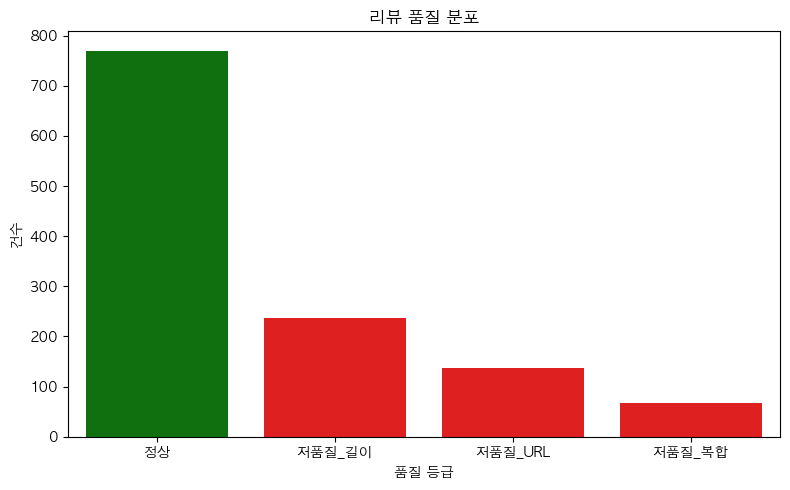

In [36]:
quality_counts = df['review_quality_final'].value_counts()

colors = ['green' if x == '정상' else 'red' 
          for x in quality_counts.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=quality_counts.index, y=quality_counts.values, palette=colors)

plt.title('리뷰 품질 분포')
plt.xlabel('품질 등급')
plt.ylabel('건수')

plt.tight_layout()
plt.show()

## 카테고리별 리뷰 비교

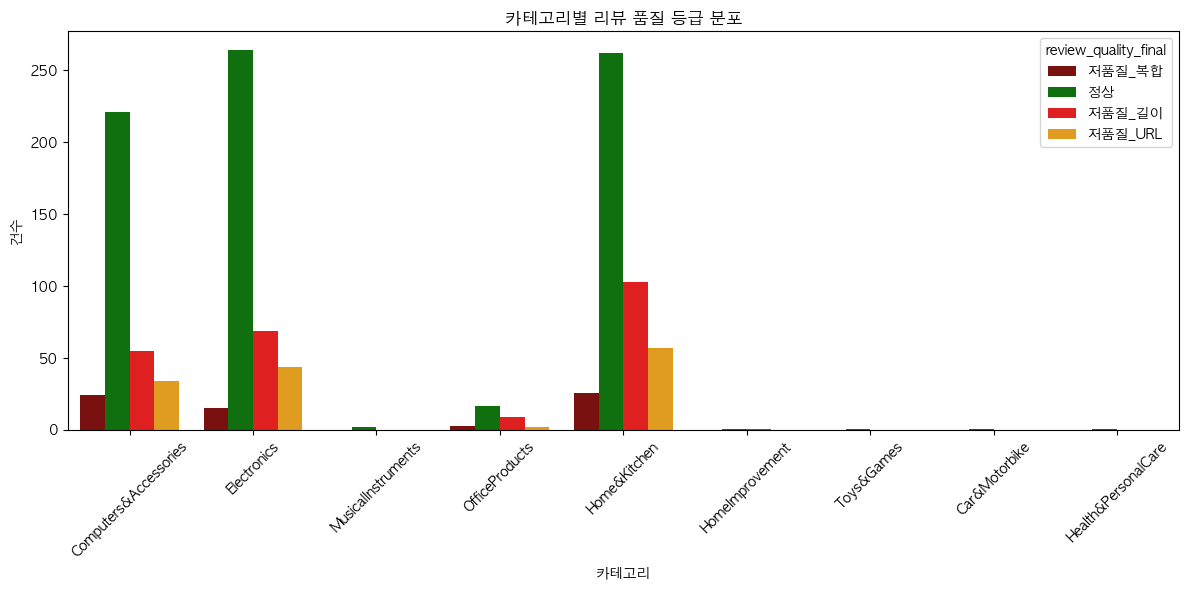

In [37]:
palette = {
    '정상'      : 'green',
    '저품질_길이': 'red',
    '저품질_URL' : 'orange',
    '저품질_복합': 'darkred'
}

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='category_main',
    hue='review_quality_final',
    palette=palette
)

plt.title('카테고리별 리뷰 품질 등급 분포')
plt.xlabel('카테고리')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Home&Kitchen 카테고리의 저품질 비율이 다른 카테고리 대비 높음 -> 일상용품 특성상 짧은 리뷰가 많이 달림
- 카테고리 리뷰 수집 시 최소 글자 제한 설정

## 카테고리별 저품질 비율 계산

In [38]:
low_quality_rate = df.groupby('category_main')['review_quality_final'].apply(
    lambda x: (x != '정상').sum() / len(x) * 100
).round(1).sort_values(ascending=False)

low_quality_rate

category_main
HomeImprovement          50.0
OfficeProducts           45.2
Home&Kitchen             41.5
Computers&Accessories    33.8
Electronics              32.7
Car&Motorbike             0.0
Health&PersonalCare       0.0
MusicalInstruments        0.0
Toys&Games                0.0
Name: review_quality_final, dtype: float64

비율 확인 시 HomeImprovement가 Home&Kitchen보다 더 높은 비율로 저품질임을 보여줌

/var/folders/r2/4_yxqx5s0t1_lv0kcts6vxj80000gn/T/ipykernel_7925/175380776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


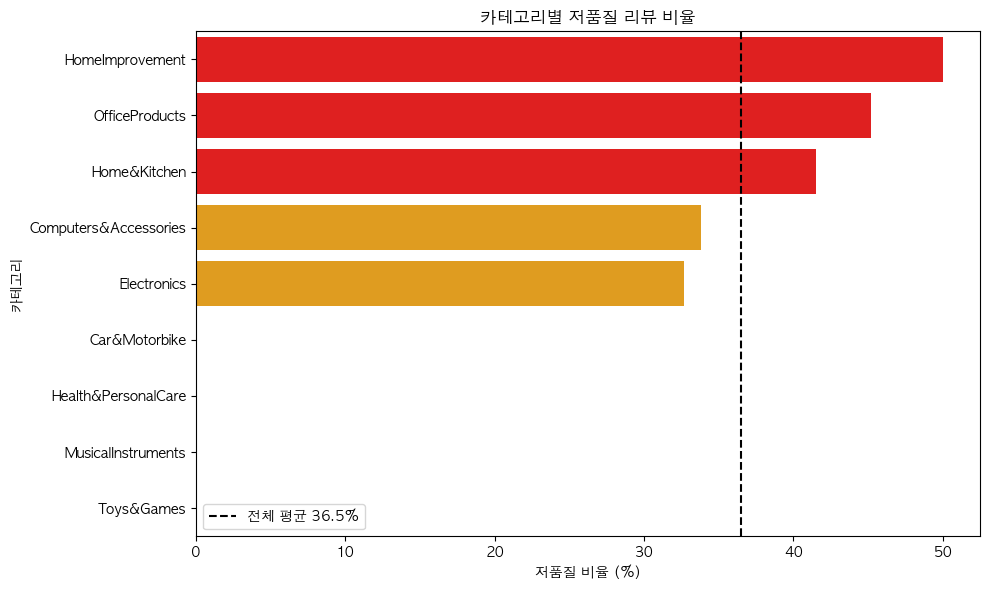

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=low_quality_rate.values,
    y=low_quality_rate.index,
    palette=['red' if v > 40 else 'orange' if v > 30 else 'green' 
             for v in low_quality_rate.values]
)

plt.title('카테고리별 저품질 리뷰 비율')
plt.xlabel('저품질 비율 (%)')
plt.ylabel('카테고리')
plt.axvline(x=36.5, color='black', linestyle='--', label='전체 평균 36.5%')
plt.legend()
plt.tight_layout()
plt.show()

## 분석 요약

- 기준 1. 텍스트 길이 (Q1 기준 492자 이하 → 저품질)
- 기준 2. URL 포함 여부 (https:// 포함 → 저품질)

카테고리별로 보면 HomeImprovement(50%), OfficeProducts(45.2%)가
전체 평균(36.5%)을 초과하는 고위험 카테고리로 확인됨.  
→ 해당 카테고리 리뷰 수집 시 최소 글자수 가이드라인 설정 필요